# Encontro 5-6: Introdução a (Estatística Descritiva, Visualização, SciPy, Seaborn & Matplotlib)

**Instrutor**: Jhonatan Lopes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

In [ ]:
arxiv_url = (
    "https://raw.githubusercontent.com/jhlopesalves/eda_humanidades/refs/heads/main/"
    "encontro_5/data/arxiv_eda_papers.csv"
)

arxiv_df = pd.read_csv(arxiv_url)

In [ ]:
arxiv_df.head()

,paper_id,title,abstract_preview,primary_category,category_label,top_level,top_level_label,year,decade,n_authors,n_versions,n_categories,title_n_words,abstract_n_words,has_doi,has_journal_ref
0,2001.04171,Multi-Sensor Data and Knowledge Fusion -- A Pr...,Fusion is a common tool for the analysis and u...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,2,1,3,12,108,False,False
1,2001.04417,Maximal Closed Set and Half-Space Separations ...,Several concept learning problems can be regar...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,3,3,2,10,170,False,False
2,2002.00509,A Machine Consciousness architecture based on ...,Recent developments in machine learning have p...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,2,2,1,11,197,False,False
3,2003.03875,Overview of the CCKS 2019 Knowledge Graph Eval...,Knowledge graph models world knowledge as conc...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,25,1,2,14,92,False,False
4,2003.06492,On Sufficient and Necessary Conditions in Boun...,Computation Tree Logic (CTL) is one of the cen...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,5,3,2,11,203,False,False


In [ ]:
arxiv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   paper_id          3387 non-null   float64
 1   title             3387 non-null   object 
 2   abstract_preview  3387 non-null   object 
 3   primary_category  3387 non-null   object 
 4   category_label    3387 non-null   object 
 5   top_level         3387 non-null   object 
 6   top_level_label   3387 non-null   object 
 7   year              3387 non-null   int64  
 8   decade            3387 non-null   object 
 9   n_authors         3387 non-null   int64  
 10  n_versions        3387 non-null   int64  
 11  n_categories      3387 non-null   int64  
 12  title_n_words     3387 non-null   int64  
 13  abstract_n_words  3387 non-null   int64  
 14  has_doi           3387 non-null   bool   
 15  has_journal_ref   3387 non-null   bool   
dtypes: bool(2), float64(1), int64(6), object(7

In [ ]:
arxiv_df.describe()

,paper_id,year,n_authors,n_versions,n_categories,title_n_words,abstract_n_words
count,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000
mean,2292.596718,2022.854739,4.202834,1.695010,2.184529,9.912902,172.085326
std,173.417154,1.732267,4.305577,0.992284,1.113424,3.524000,47.876997
min,2001.005640,2020.000000,1.000000,1.000000,1.000000,2.000000,38.000000
25%,2111.029495,2021.000000,2.000000,1.000000,1.000000,7.000000,139.000000
50%,2307.146420,2023.000000,4.000000,1.000000,2.000000,10.000000,171.000000
75%,2412.003215,2024.000000,5.000000,2.000000,3.000000,12.000000,204.000000
max,2602.111590,2025.000000,182.000000,8.000000,8.000000,32.000000,310.000000


In [ ]:
arxiv_df = arxiv_df.astype(
    {
        "paper_id": "string",
        "title": "string",
        "abstract_preview": "string",
        "primary_category": "category",
        "category_label": "category",
        "top_level": "category",
        "top_level_label": "category",
        "decade": "category",
        "has_doi": "bool",
        "has_journal_ref": "bool",
    }
)

arxiv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   paper_id          3387 non-null   string  
 1   title             3387 non-null   string  
 2   abstract_preview  3387 non-null   string  
 3   primary_category  3387 non-null   category
 4   category_label    3387 non-null   category
 5   top_level         3387 non-null   category
 6   top_level_label   3387 non-null   category
 7   year              3387 non-null   int64   
 8   decade            3387 non-null   category
 9   n_authors         3387 non-null   int64   
 10  n_versions        3387 non-null   int64   
 11  n_categories      3387 non-null   int64   
 12  title_n_words     3387 non-null   int64   
 13  abstract_n_words  3387 non-null   int64   
 14  has_doi           3387 non-null   bool    
 15  has_journal_ref   3387 non-null   bool    
dtypes: bool(2), category(5),

In [ ]:
arxiv_df.describe()

,year,n_authors,n_versions,n_categories,title_n_words,abstract_n_words
count,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000
mean,2022.854739,4.202834,1.695010,2.184529,9.912902,172.085326
std,1.732267,4.305577,0.992284,1.113424,3.524000,47.876997
min,2020.000000,1.000000,1.000000,1.000000,2.000000,38.000000
25%,2021.000000,2.000000,1.000000,1.000000,7.000000,139.000000
50%,2023.000000,4.000000,1.000000,2.000000,10.000000,171.000000
75%,2024.000000,5.000000,2.000000,3.000000,12.000000,204.000000
max,2025.000000,182.000000,8.000000,8.000000,32.000000,310.000000


## `n_categories`

In [ ]:
arxiv_df["n_categories"].describe()

,n_categories
count,3387.000000
mean,2.184529
std,1.113424
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,8.000000


## Toda medida de centro ou comparação precisa vir acompanhada de alguma noção de variação, dispersão ou incerteza.

- qual é o centro?
- quanta variação existe?
- a distribuição é simétrica ou assimétrica?
- há valores extremos?
- o gráfico confirma ou complica o resumo numérico?

### Standard Deviation (desvio padrão)

**Fórmula (Amostral):**
$$ s = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}} $$

**Onde:**
*   $s$ é o desvio padrão amostral.
*   $x_i$ representa cada valor individual no conjunto de dados.
*   $\bar{x}$ é a média aritmética dos valores.
*   $n$ é o número total de observações na amostra.

**DESVIO PADRÃO EM SLOW-MOTION - INVESTIGANDO FÓRMULAS!**

In [ ]:
values = arxiv_df["n_categories"]

x_bar = values.mean()
n = len(values)

sum_of_squared_deviations = np.sum(
    [
        (x_i - x_bar)
        ** 2  # Correção: parênteses ao redor da subtração antes de elevar ao quadrado
        for x_i in values  # O loop que passa por cada valor
    ]
)

# Dividir por (n-1) para obter a variância amostral
sample_variance = sum_of_squared_deviations / (n - 1)

# Tirar a raiz quadrada da variância para obter o desvio padrão
sample_standard_deviation = np.sqrt(sample_variance)

print(f"Média: {x_bar:.3f}")
print(f"Soma dos desvios quadráticos: {sum_of_squared_deviations:.3f}")
print(f"Variância amostral: {sample_variance:.3f}")
print(f"Desvio padrão amostral: {sample_standard_deviation:.3f}")

Média: 2.185
Soma dos desvios quadráticos: 4197.669
Variância amostral: 1.240
Desvio padrão amostral: 1.113


A variância é matematicamente fundamental, mas nem sempre é a medida mais intuitiva para comunicação inicial.

Por isso, em muitos resumos descritivos, reportamos o desvio padrão, que é a raiz quadrada da variância e volta para a unidade original da variável.

In [ ]:
std_categories = arxiv_df["n_categories"].std(ddof=1)
var_categories = arxiv_df["n_categories"].var(ddof=1)

print(f"Standard Deviation: {std_categories:.3f}")
print(f"Variance: {var_categories:.3f}")

Standard Deviation: 1.113
Variance: 1.240


### Plot "feio": apenas para uso interno exploratório

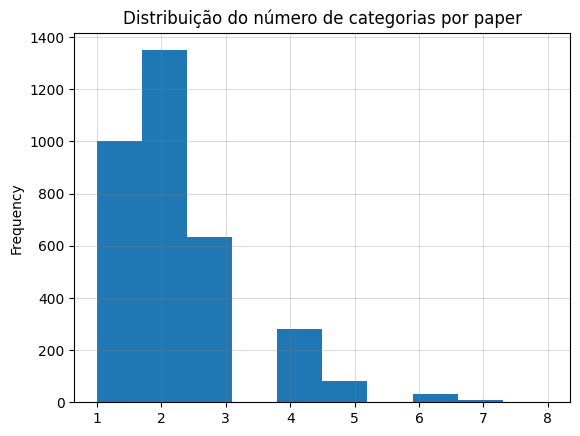

In [ ]:
arxiv_df["n_categories"].plot(kind="hist")
plt.title("Distribuição do número de categorias por paper")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")
plt.show()

### Seaborn: a opção elegante para publicações.

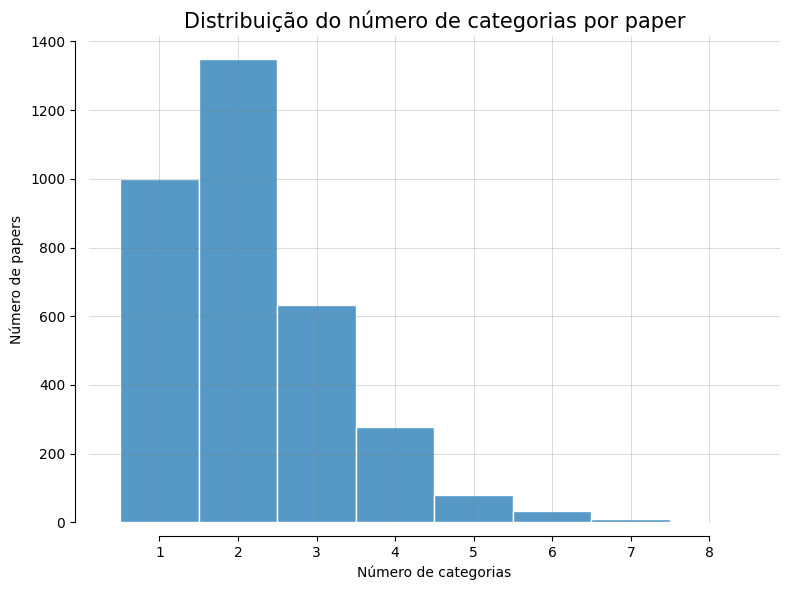

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=arxiv_df,
    x="n_categories",
    discrete=True,
    ax=ax,
    edgecolor="white",
)

ax.set_title("Distribuição do número de categorias por paper", fontsize=15)
ax.set(
    xlabel="Número de categorias",
    ylabel="Número de papers",
)
ax.grid(True, alpha=0.4, linewidth=0.5, color="grey")


sns.despine(ax=ax, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

### Histogramas são 'manipuláveis'

### 15 bins

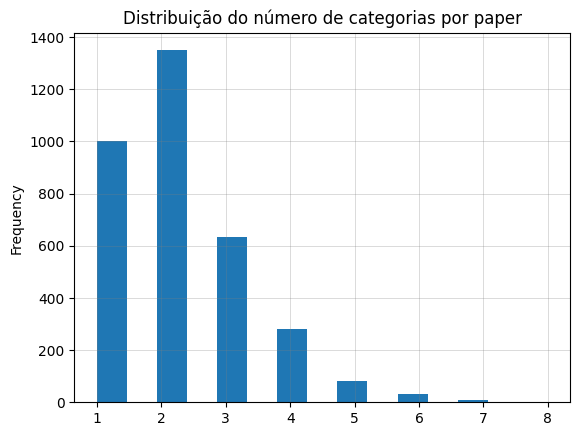

In [ ]:
arxiv_df["n_categories"].plot(kind="hist", bins=15)
plt.title("Distribuição do número de categorias por paper")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")
plt.show()

12 bins

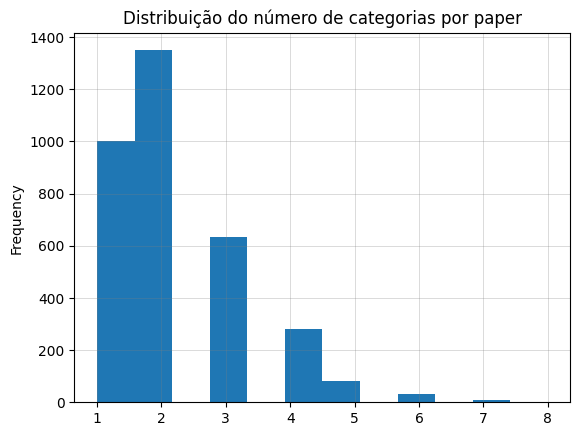

In [ ]:
arxiv_df["n_categories"].plot(kind="hist", bins=12)
plt.title("Distribuição do número de categorias por paper")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")
plt.show()

### 7 bins

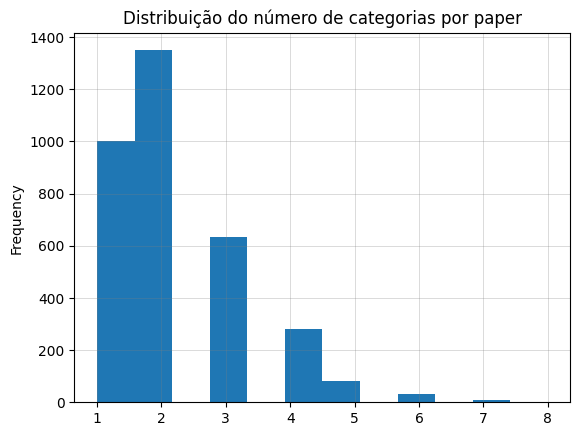

In [ ]:
arxiv_df["n_categories"].plot(kind="hist", bins=12)
plt.title("Distribuição do número de categorias por paper")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")
plt.show()

### Simulando uma distribuição normal com base nas estatísticas da coluna `n_categories`

In [ ]:
rng = np.random.default_rng(seed=42)

normal_df = pd.DataFrame(
    {
        "value": rng.normal(
            loc=arxiv_df["n_categories"].mean(),
            scale=arxiv_df["n_categories"].std(ddof=1),
            size=len(arxiv_df),
        )
    }
)

normal_df.describe()

,value
count,3387.000000
mean,2.160591
std,1.113605
min,-1.877702
25%,1.423143
50%,2.186021
75%,2.892821
max,5.723942


## Uma distribuição normal como contraste visual

A distribuição normal é uma referência comum em estatística.Mas nem toda variável precisa se parecer com uma normal.

Aqui, vamos simular uma distribuição normal apenas como contraste visual.
A pergunta não é “nossos dados são normais?”.
A pergunta é:

> que forma nossos dados têm, e por que essa forma importa?

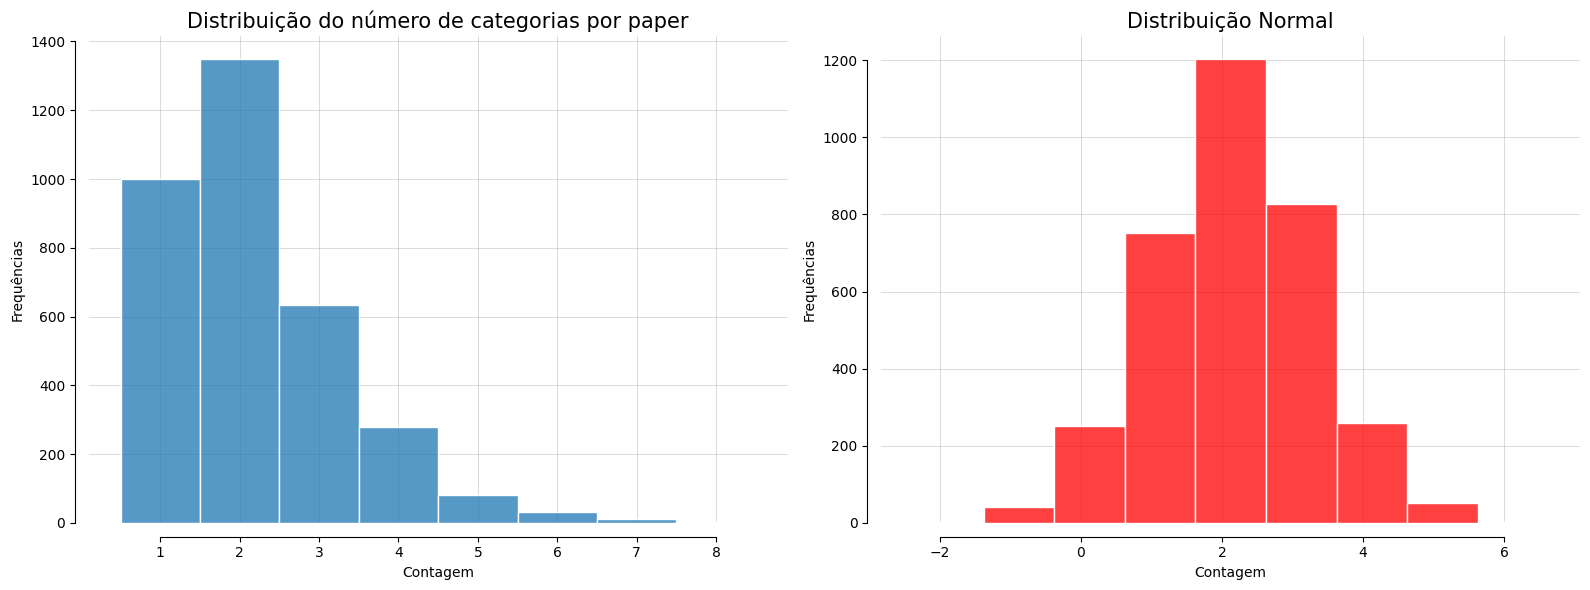

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.histplot(
    data=arxiv_df,
    x="n_categories",
    discrete=True,
    ax=ax1,
    edgecolor="white",
)

ax1.set_title("Distribuição do número de categorias por paper", fontsize=15)
ax1.set(xlabel="Contagem", ylabel="Frequências")
ax1.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax1.set_axisbelow(True)

sns.histplot(
    data=normal_df,
    x="value",
    discrete=True,
    ax=ax2,
    color="r",
    edgecolor="white",
)

ax2.set_title("Distribuição Normal", fontsize=15)
ax2.set(xlabel="Contagem", ylabel="Frequências")
ax2.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax2.set_axisbelow(True)

sns.despine(fig=fig, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

## ECDF

ECDF significa Empirical Cumulative Distribution Function.

Ele responde uma pergunta simples:

> qual proporção dos dados está abaixo ou igual a determinado valor?

Por exemplo, se no eixo x temos `n_categories = 2` e no eixo y temos 80%, isso significa que 80% dos papers têm até 2 categorias.

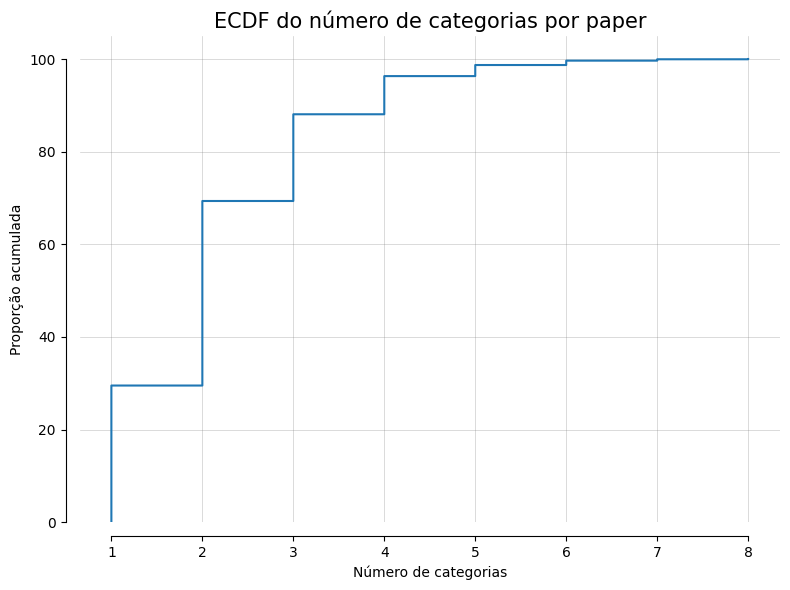

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.ecdfplot(
    data=arxiv_df,
    x="n_categories",
    ax=ax,
    stat="percent",
)

ax.set_title("ECDF do número de categorias por paper", fontsize=15)
ax.set(
    xlabel="Número de categorias",
    ylabel="Proporção acumulada",
)
ax.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax.set_axisbelow(True)

sns.despine(ax=ax, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

### Comparando `n_absences` com um ECDF de uma distribuição normal

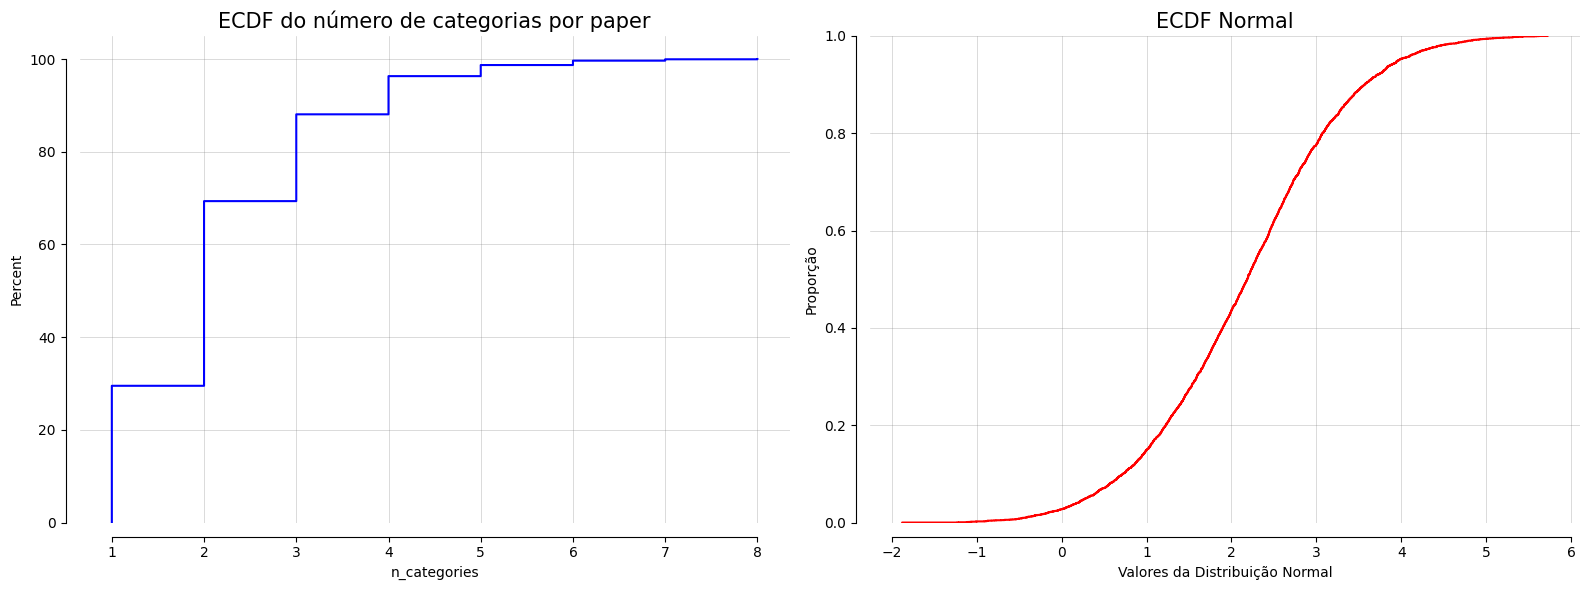

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.ecdfplot(
    data=arxiv_df,
    x="n_categories",
    ax=ax1,
    color="b",
    stat="percent",
)

ax1.set_title("ECDF do número de categorias por paper", fontsize=15)
ax.set(
    xlabel="Número de categorias",
    ylabel="Proporção acumulada",
)
ax1.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax1.set_axisbelow(True)

sns.ecdfplot(
    data=normal_df,
    x="value",
    ax=ax2,
    color="r",
)

ax2.set_title("ECDF Normal", fontsize=15)
ax2.set(xlabel="Valores da Distribuição Normal", ylabel="Proporção")
ax2.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax2.set_axisbelow(True)

sns.despine(fig=fig, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

## Distribuições normais com as mesmas estatísticas, mas com um número maior de 'data points'

In [ ]:
rng = np.random.default_rng(seed=42)

normal_bigger_n = pd.DataFrame(
    {
        "value": rng.normal(
            loc=arxiv_df["n_categories"].mean(),
            scale=arxiv_df["n_categories"].std(ddof=1),
            size=100_000,
        )
    }
)

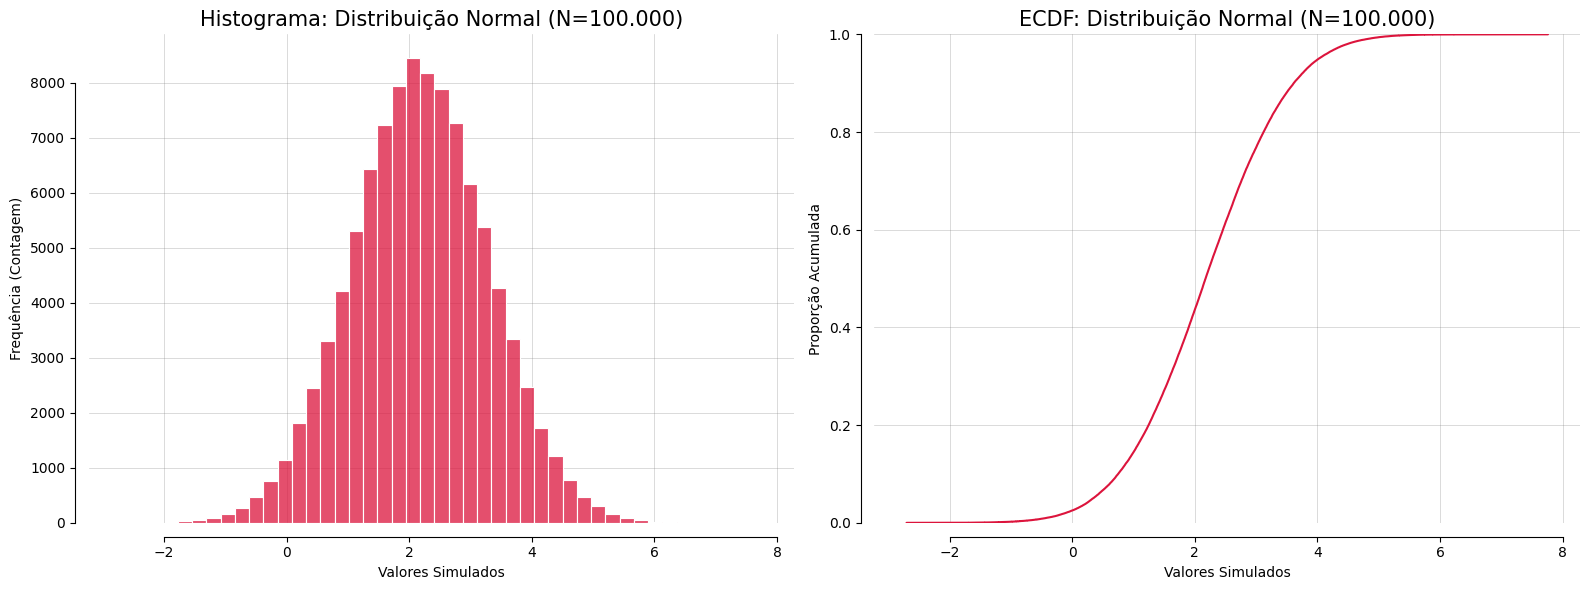

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.histplot(
    data=normal_bigger_n,
    x="value",
    bins=45,
    color="crimson",
    ax=ax1,
    edgecolor="white",
)

ax1.set_title("Histograma: Distribuição Normal (N=100.000)", fontsize=15)
ax1.set(xlabel="Valores Simulados", ylabel="Frequência (Contagem)")
ax1.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax1.set_axisbelow(True)

sns.ecdfplot(
    data=normal_bigger_n,
    x="value",
    ax=ax2,
    color="crimson",
)

ax2.set_title("ECDF: Distribuição Normal (N=100.000)", fontsize=15)
ax2.set(xlabel="Valores Simulados", ylabel="Proporção Acumulada")
ax2.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax2.set_axisbelow(True)

sns.despine(fig=fig, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

# Encontro 6 começa aqui.

In [ ]:
def plot_hist_ecdf(
    dataframe: pd.DataFrame,
    column: str,
    variable_label: str,
    bins: int = 30,
    discrete: bool = False,
    colors: list = None,
) -> None:

    values = dataframe[column].dropna()

    mean_value = values.mean()
    median_value = values.median()

    fig, (ax1, ax2) = plt.subplots(
        ncols=2,
        figsize=(14, 5),
    )

    if colors is None:
        hist_color = None  # Usa a cor padrão do Seaborn
        ecdf_color = None  # Usa a cor padrão do Seaborn
    else:
        hist_color = colors[0]  # Pega a primeira cor da lista (índice 0)
        ecdf_color = colors[1]  # Pega a segunda cor da lista (índice 1)

    sns.histplot(
        data=dataframe,
        x=column,
        bins=bins,
        discrete=discrete,
        edgecolor="white",
        color=hist_color,
        ax=ax1,
    )

    ax1.axvline(
        mean_value,
        linestyle="--",
        color="crimson",
        label=f"Media: {mean_value:.2f}",
    )

    ax1.axvline(
        median_value,
        linestyle="-",
        label=f"Mediana: {median_value:.2f}",
    )

    ax1.set_title(f"Histograma: {variable_label}", fontsize=14)
    ax1.set(
        xlabel=variable_label,
        ylabel="Número de observações",
    )
    ax1.legend()

    sns.ecdfplot(
        x=values,
        stat="percent",
        color=ecdf_color,
        ax=ax2,
    )

    ax2.set_title(f"ECDF: {variable_label}", fontsize=14)
    ax2.set(
        xlabel=variable_label,
        ylabel="Porcentagem acumulada",
    )

    for axis in (ax1, ax2):
        axis.grid(True, alpha=0.4, linewidth=0.5, color="grey")
        axis.set_axisbelow(True)

    sns.despine(
        fig=fig,
        top=True,
        right=True,
        trim=True,
        offset=10,
    )

    plt.tight_layout()
    plt.show()

## Protocolo mínimo para uma variável numérica

Para começar a entender uma variável numérica, podemos combinar:

1. `.describe()`;
2. histograma;
3. ECDF.

O `.describe()` dá números.

O histograma mostra a forma geral.

O ECDF mostra a acumulação dos valores sem depender de bins.

Nenhum deles sozinho é suficiente.

Juntos, eles dão uma primeira leitura muito mais responsável.

In [ ]:
plot_hist_ecdf(
    dataframe=arxiv_df,
    column="n_categories",
    variable_label="Número de categorias por paper",
    discrete=True,
    colors=["steelblue", "blue"],
)


## Segunda variável: tamanho dos abstracts

`n_categories` era uma variável discreta pequena.

Agora vamos analisar `abstract_n_words`.

Essa variável é mais próxima do nosso interesse como linguistas e pesquisadores de texto, porque descreve uma propriedade textual: o tamanho do abstract.

In [ ]:
arxiv_df["n_categories"].describe()

In [ ]:
sns.set_color_codes(palette="bright")

“Em alguns domínios, variância muito maior que média seria red flag; em textos, isso pode ser parte do fenômeno.”

In [ ]:
arxiv_df["abstract_n_words"].describe()

In [ ]:
abstract_values = arxiv_df["abstract_n_words"]

abstract_mean = abstract_values.mean()
abstract_var = abstract_values.var(ddof=1)

print(f"Média dos abstracts: {abstract_mean:.2f}")
print(f"Variância dos abstracts: {abstract_var:.2f}")
print(f"Razão variância/media: {abstract_var / abstract_mean:.2f}")

In [ ]:
plot_hist_ecdf(
    dataframe=arxiv_df,
    column="n_categories",
    variable_label="Número de palabras por Abstract",
    discrete=True,
    colors=["b", "blue"],
)


Q-Q Plot: Um plot robusto para verificação de normalidade

# Feioso
fig, ax = plt.subplots(figsize=(8, 5))

stats.probplot(
    arxiv_df["abstract_n_words"],
    dist="norm",
    plot=ax,
)

points, fit_line = ax.lines


plt.tight_layout()
plt.show()

In [ ]:
# Elegante: Seaborn

fig, ax = plt.subplots(figsize=(8, 5))

stats.probplot(
    arxiv_df["abstract_n_words"],
    dist="norm",
    plot=ax,
)

points, fit_line = ax.lines

points.set(
    markeredgecolor="white",
    markersize=8,
    alpha=0.4,
)

fit_line.set(
    color="crimson",
    linewidth=1.8,
    linestyle="--",
)

ax.set(
    xlabel="Theoretical Quantiles (Normal Dist.)",
    ylabel="Valores observados: palavras no abstract",
)

ax.set_title("Q-Q Plot Numero de Palavras por Abstract", pad=10, fontsize=14)

ax.grid(alpha=0.4, linewidth=0.5, color="grey")
sns.despine(ax=ax, top=True, trim=True, offset=10)

plt.tight_layout()
plt.show()


In [ ]:
rng = np.random.default_rng(seed=42)

poisson_df = pd.DataFrame(
    {
        "abstract_n_words_poisson": rng.poisson(
            lam=abstract_mean,
            size=len(arxiv_df),
        )
    }
)

pd.concat(
    [
        abstract_values.describe().rename("real"),
        poisson_df["abstract_n_words_poisson"].describe().rename("poisson"),
    ],
    axis=1,
)


In [ ]:
print(f"Variance abstract_n_words: {arxiv_df['abstract_n_words'].var():.2f}")
print(f"Variance experimento: {poisson_df['abstract_n_words_poisson'].var():.2f}")


## 3. Quais áreas aparecem no dataset?

Uma primeira pergunta categórica é:

> quais áreas aparecem no nosso recorte?


In [ ]:
arxiv_df["primary_category"].value_counts()

### Normalised Shannon Entropy

**Fórmula:**
$$ H_{norm} = \frac{H}{H_{max}} = \frac{-\sum_{i=1}^{n} p_i \ln(p_i)}{\ln(n)} $$

**Onde:**
*   $p_i$ é a proporção (probabilidade) de artigos na categoria $i$.
*   $n$ é o número total de categorias únicas.
*   $H$ é a Entropia de Shannon bruta, que mede a incerteza ou diversidade da distribuição.
*   $H_{max} = \ln(n)$ é a entropia máxima possível, que ocorre quando todas as categorias têm exatamente o mesmo número de artigos.

**Interpretação:**
*   **$H_{norm} = 0$:** Todos os itens pertencem a uma única categoria (diversidade mínima / previsibilidade completa).
*   **$H_{norm} = 1$:** Os itens estão perfeitamente e uniformemente distribuídos entre todas as categorias disponíveis (diversidade máxima / imprevisibilidade completa).

In [ ]:
def normalised_shannon_entropy(series: pd.Series) -> float:

    proportions = series.value_counts(normalize=True, dropna=False)
    proportions = proportions[proportions > 0]

    entropy = stats.entropy(proportions, base=np.e)
    max_entropy = np.log(len(proportions))

    if max_entropy == 0:
        return 0.0

    return entropy / max_entropy

In [ ]:
norm_entropy_categories = normalised_shannon_entropy(arxiv_df["readable_category"])

print(f"Normalised Entropy for categories: {norm_entropy_categories:.4f}")


In [ ]:
categorical_entropy = (
    arxiv_df.select_dtypes(include=["category", "string", "object", "bool"])
    .apply(normalised_shannon_entropy)
    .sort_values()
)

categorical_entropy
